In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
Titanic=pd.read_csv('Titanic-Dataset.csv')

In [4]:
Titanic.shape

(891, 12)

In [5]:
Titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [7]:
Titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
Titanic['Age'] = Titanic['Age'].fillna(Titanic['Age'].median())


In [9]:
Titanic['Embarked'] = Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0])


In [10]:
Titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [11]:
Titanic['Cabin available'] = Titanic['Cabin'].notna().astype(int)
Titanic.drop(columns=["Cabin"],inplace=True)


In [12]:
Titanic.isnull().sum()              

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Cabin available    0
dtype: int64

In [13]:
survival_counts = Titanic["Survived"].value_counts()
survival_counts

Survived
0    549
1    342
Name: count, dtype: int64

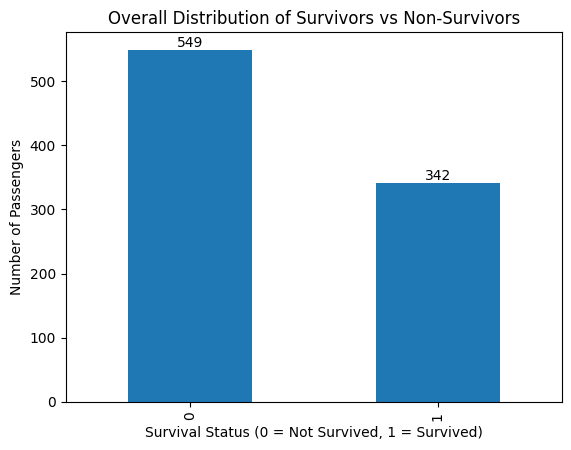

In [14]:
plt.figure()
survival_counts.plot(kind="bar")
plt.xlabel("Survival Status (0 = Not Survived, 1 = Survived)")
plt.ylabel("Number of Passengers")
plt.title("Overall Distribution of Survivors vs Non-Survivors")
for i,values in enumerate(survival_counts.values):
    plt.text(i,values,str(values),ha='center',va='bottom')
plt.show()

In [15]:
gender=Titanic.groupby('Sex')['Survived'].count()
gender

Sex
female    314
male      577
Name: Survived, dtype: int64

In [16]:
gender_survival = Titanic.groupby("Sex")["Survived"].mean() * 100
gender_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

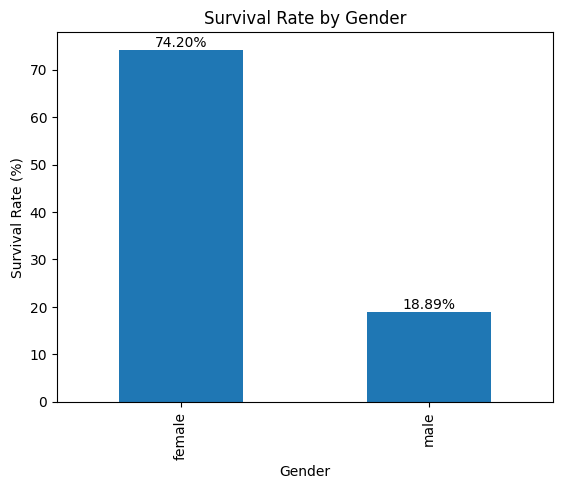

In [17]:
plt.figure()
gender_survival.plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Gender")
for i,value in enumerate(gender_survival.values):
    plt.text(i,value,f'{value:.2f}%',ha='center',va='bottom')

plt.show()

In [19]:
passanger_class=Titanic.groupby('Pclass')['Survived'].count()
passanger_class

Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64

In [20]:
class_survival = Titanic.groupby("Pclass")["Survived"].mean() * 100

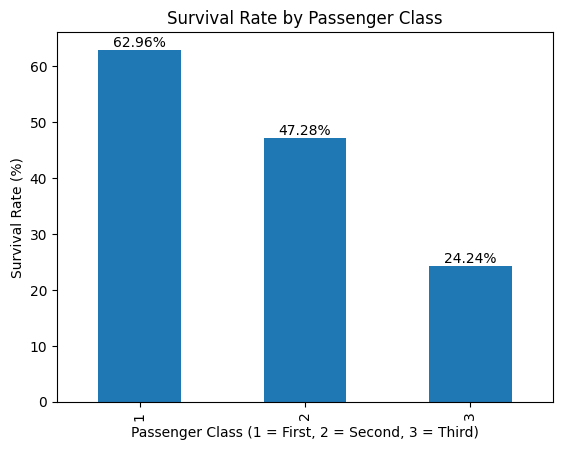

In [21]:
plt.figure()
class_survival.plot(kind="bar")
plt.xlabel("Passenger Class (1 = First, 2 = Second, 3 = Third)")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class")

for i, value in enumerate(class_survival.values):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

In [22]:
Titanic['Age'].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

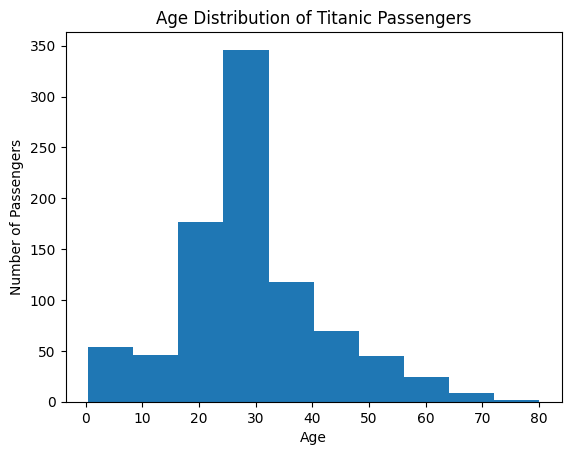

In [23]:

plt.figure()
Titanic['Age'].plot(kind="hist")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution of Titanic Passengers")
plt.show()

In [24]:
survivors = Titanic[Titanic["Survived"] == 1]['Age']


In [25]:
not_survivors = Titanic[Titanic["Survived"] == 0]['Age']


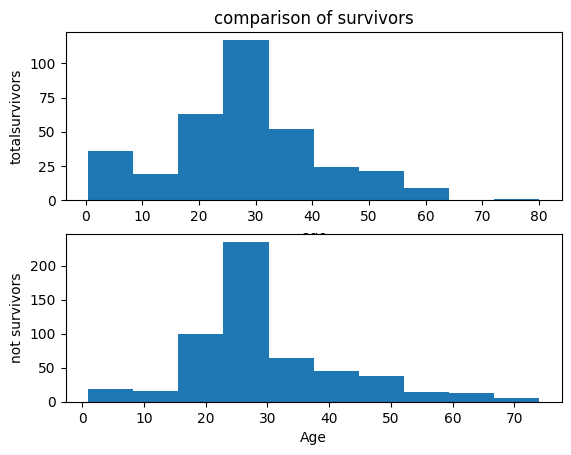

In [26]:
plt.subplot(2,1,1)
survivors.plot(kind='hist',label='survivors')
plt.xlabel('age')
plt.ylabel('totalsurvivors')
plt.title('comparison of survivors')
 
plt.subplot(2,1,2)
not_survivors.plot(kind='hist',label='not_survivors')
plt.xlabel('Age')
plt.ylabel('not survivors')
plt.show()



In [28]:
passangerclass=Titanic.groupby('Pclass')['Fare'].mean()
passangerclass

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

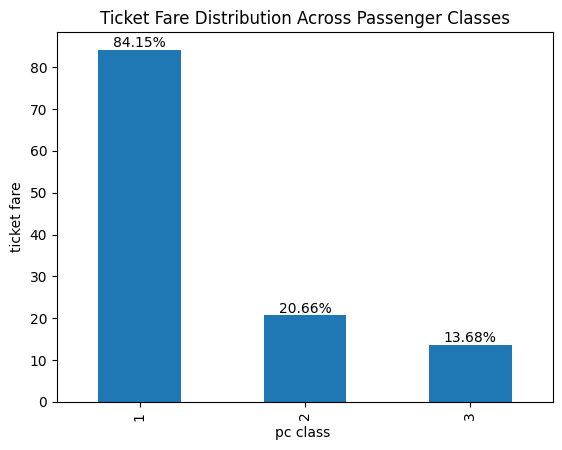

In [29]:
plt.figure()
passangerclass.plot(kind="bar")
plt.xlabel("pc class ")
plt.ylabel("ticket fare")
plt.title("Ticket Fare Distribution Across Passenger Classes")
for i, value in enumerate(passangerclass.values):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')
plt.show()

In [31]:
passanger_embarked=Titanic.groupby('Embarked')['PassengerId'].count()
passanger_embarked


Embarked
C    168
Q     77
S    646
Name: PassengerId, dtype: int64

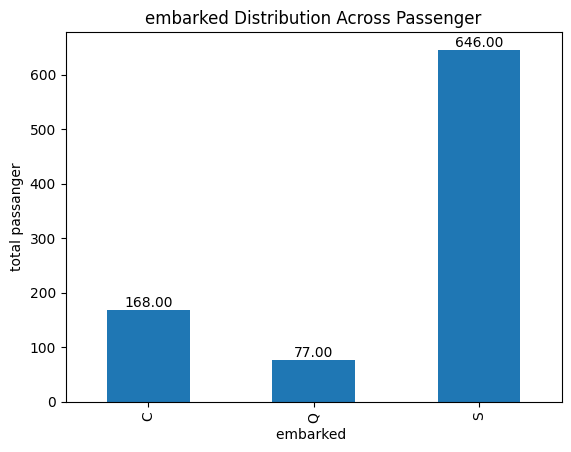

In [32]:
plt.figure()
passanger_embarked.plot(kind="bar")
plt.xlabel("embarked ")
plt.ylabel("total passanger")
plt.title("embarked Distribution Across Passenger")
for i, value in enumerate(passanger_embarked.values):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.show()

In [48]:
import seaborn as sns

In [49]:
numerical_data=Titanic.select_dtypes(include=['int64','float64'])
corr_matrix=numerical_data.corr()

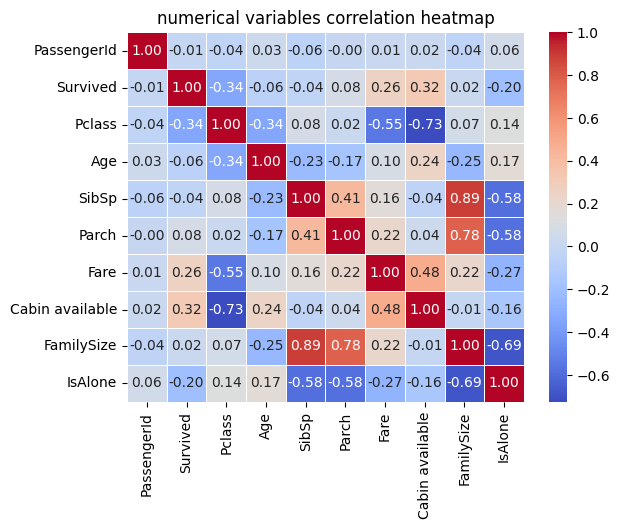

In [50]:
plt.Figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('numerical variables correlation heatmap')
plt.show()

In [51]:
Titanic["FamilySize"] = Titanic["SibSp"] + Titanic["Parch"] + 1

In [52]:
family_surviva = Titanic.groupby("FamilySize")["Survived"].mean() * 100
family_surviva

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

In [53]:
family_survival=family_surviva.head(7)

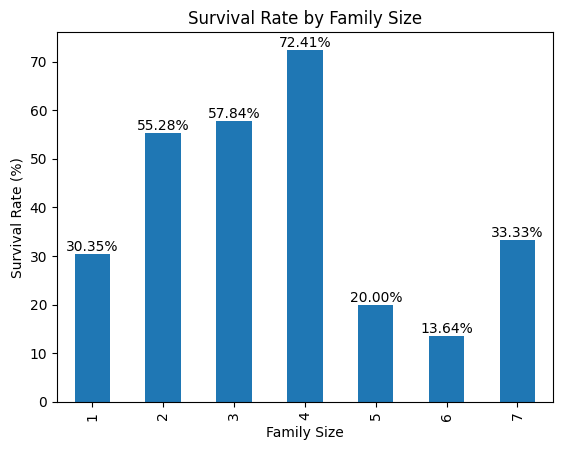

In [54]:
plt.figure()
family_survival.plot(kind="bar")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Family Size")
for i, value in enumerate(family_survival.values):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')
plt.show()

In [55]:
Titanic["IsAlone"] = (Titanic["FamilySize"] == 1).astype(int)

In [56]:
alone_survival = Titanic.groupby("IsAlone")["Survived"].mean() * 100
alone_survival

IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64

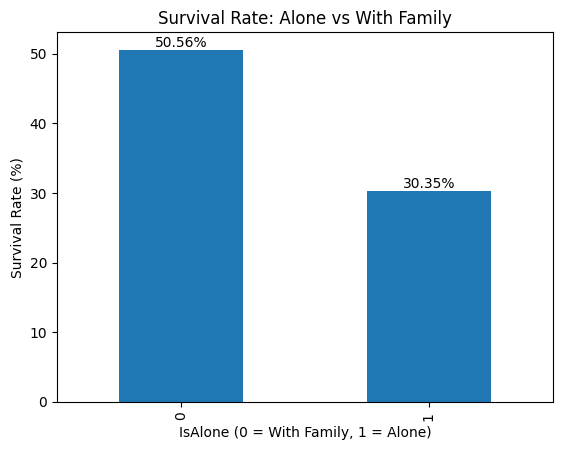

In [57]:
plt.figure()
alone_survival.plot(kind="bar")
plt.xlabel("IsAlone (0 = With Family, 1 = Alone)")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate: Alone vs With Family")
for i, value in enumerate(alone_survival.values):
    plt.text(i, value, f'{value:.2f}%', ha='center', va='bottom')
plt.show()

In [58]:
Titanic['title']=Titanic['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\admin\AppData\Local\Temp\ipykernel_18048\1416264046.py:1: SyntaxWarning: invalid escape sequence '\.'
  Titanic['title']=Titanic['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)


In [59]:
title_survival = Titanic.groupby("title")["Survived"].mean().sort_values(ascending=False) * 100
title_survival

title
Countess    100.000000
Ms          100.000000
Lady        100.000000
Mme         100.000000
Mlle        100.000000
Sir         100.000000
Mrs          79.200000
Miss         69.780220
Master       57.500000
Major        50.000000
Col          50.000000
Dr           42.857143
Mr           15.667311
Capt          0.000000
Don           0.000000
Jonkheer      0.000000
Rev           0.000000
Name: Survived, dtype: float64

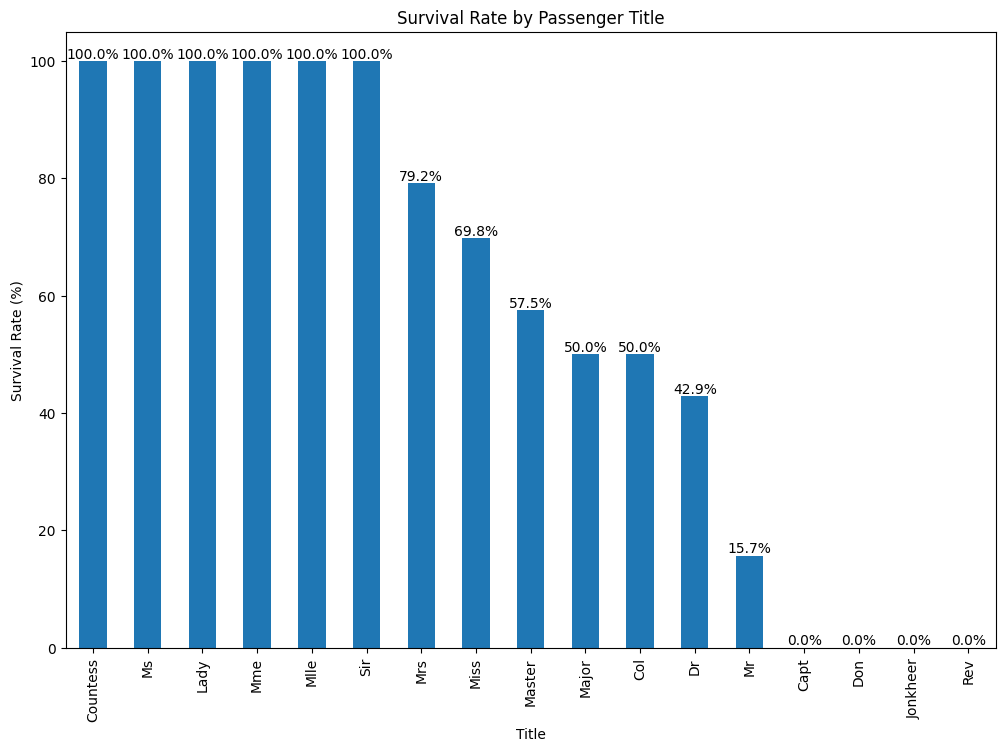

In [60]:
plt.figure(figsize=(12,8))
title_survival.plot(kind="bar")
plt.xlabel("Title")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Title")
for i, value in enumerate(title_survival.values):
    plt.text(i, value, f'{value:.1f}%', ha='center', va='bottom')
plt.show()


In [61]:
Titanic["AgeGroup"] = pd.cut(
    Titanic["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)


In [62]:
age_survival = Titanic.groupby("AgeGroup")["Survived"].mean() * 100
age_survival

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64

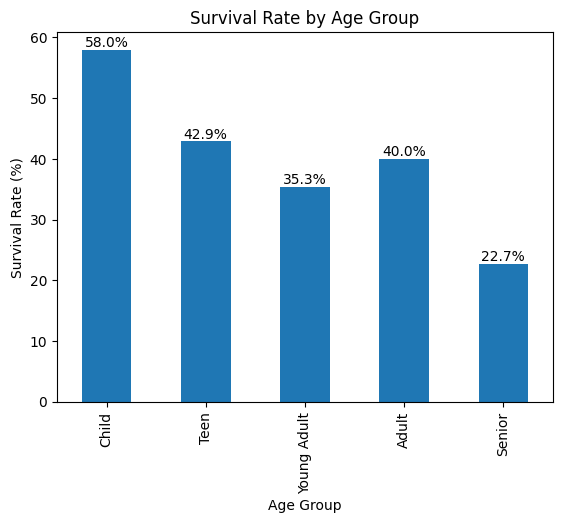

In [63]:
plt.figure()
age_survival.plot(kind="bar")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Age Group")
for i, value in enumerate(age_survival.values):
    plt.text(i, value, f'{value:.1f}%', ha='center', va='bottom')
plt.show()

In [64]:
Titanic.to_csv('Titanic.csv')